In [25]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.decomposition import TruncatedSVD
from scipy.cluster.hierarchy import dendrogram, linkage
%pip install gensim
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from collections import Counter





[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#loading the data

In [26]:

df = pd.read_csv('../complete_preprocessing_final.csv')
df = df.dropna(subset=['trunc_processed_text']).reset_index(drop=True)
df['trunc_processed_text'] = df['trunc_processed_text'].astype(str)
true_labels = pd.Categorical(df['type']).codes

print(f"Loaded {len(df):,} tickets")
print(f"Types: {df['type'].value_counts().to_dict()}")

Loaded 27,919 tickets
Types: {'Incident': 11093, 'Request': 8030, 'Problem': 5832, 'Change': 2964}


# Create TF-IDF vectors

In [27]:


vectorizer = TfidfVectorizer(
    max_features=5000,
    max_df=0.95,
    min_df=5
)

X_tfidf = vectorizer.fit_transform(df['trunc_processed_text'])
texts = df['trunc_processed_text'].tolist()
true_labels = df['type'].values

print(f"\n✓ TF-IDF matrix: {X_tfidf.shape}")
print(f"  Documents: {X_tfidf.shape[0]:,}")
print(f"  Features:  {X_tfidf.shape[1]:,}")


✓ TF-IDF matrix: (27919, 2469)
  Documents: 27,919
  Features:  2,469


In [28]:
def get_coherence(texts, labels, n_top=10):
  
    tokenized = [text.split() for text in texts]
    dictionary = Dictionary(tokenized)
    

    topics = []
    for cluster_id in np.unique(labels):
        cluster_docs = [texts[i] for i in range(len(texts)) if labels[i] == cluster_id]
        
       
        word_freq = Counter()
        for doc in cluster_docs[:1000]:  
            word_freq.update(doc.split())
        
        top_words = [word for word, count in word_freq.most_common(n_top)]
        if top_words:
            topics.append(top_words)
    
   
    if len(topics) < 2:
        return 0.0
    
    cm = CoherenceModel(
        topics=topics,
        texts=tokenized,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    return cm.get_coherence()



# K means clustering with multi k values multi seeds

In [29]:

print("K MEANS CLUSTERING: MULTI K, MULTI SEED ANALYSIS")

CANDIDATE_K = [3, 5, 7, 10, 15]
SEEDS = [42, 123, 456, 789]

kmeans_results = []



for k in CANDIDATE_K:
    seed_labels = []
    
    for seed in SEEDS:
      
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(X_tfidf)
        seed_labels.append(labels)
        
      
        sil = silhouette_score(X_tfidf, labels, metric='cosine')
        ari = adjusted_rand_score(true_labels, labels)
        nmi = normalized_mutual_info_score(true_labels, labels)
        coh = get_coherence(texts, labels, n_top=10)
        inertia = km.inertia_
        
        kmeans_results.append({
            'k': k,
            'seed': seed,
            'silhouette': round(sil, 4),
            'ARI': round(ari, 4),
            'NMI': round(nmi, 4),
            'coherence': round(coh, 4),
            'inertia': round(inertia, 2)
        })
        
        print(f"  k={k:2d}, seed={seed:3d} → sil={sil:.4f}, ARI={ari:.4f}, "
              f"NMI={nmi:.4f}, coh={coh:.4f}")
    
   
    ari_pairs = []
    for i in range(len(SEEDS)):
        for j in range(i+1, len(SEEDS)):
            ari_pairs.append(adjusted_rand_score(seed_labels[i], seed_labels[j]))
    
    stability = np.mean(ari_pairs)
  
    for row in kmeans_results:
        if row['k'] == k and 'stability' not in row:
            row['stability'] = round(stability, 4)
    
    print(f"  → Stability ARI (k={k}): {stability:.4f}\n")


kmeans_df = pd.DataFrame(kmeans_results)


print(kmeans_df.to_string(index=False))

kmeans_df.to_csv('../Outputs/kmeans_results.csv', index=False)


K MEANS CLUSTERING: MULTI K, MULTI SEED ANALYSIS
  k= 3, seed= 42 → sil=0.0546, ARI=0.2950, NMI=0.2905, coh=0.7095
  k= 3, seed=123 → sil=0.0546, ARI=0.2948, NMI=0.2900, coh=0.7095
  k= 3, seed=456 → sil=0.0546, ARI=0.2953, NMI=0.2903, coh=0.7095
  k= 3, seed=789 → sil=0.0546, ARI=0.2947, NMI=0.2898, coh=0.7095
  → Stability ARI (k=3): 0.9982

  k= 5, seed= 42 → sil=0.0604, ARI=0.2469, NMI=0.2456, coh=0.7737
  k= 5, seed=123 → sil=0.0604, ARI=0.2465, NMI=0.2449, coh=0.7737
  k= 5, seed=456 → sil=0.0604, ARI=0.2469, NMI=0.2457, coh=0.7737
  k= 5, seed=789 → sil=0.0605, ARI=0.2462, NMI=0.2445, coh=0.7737
  → Stability ARI (k=5): 0.9966

  k= 7, seed= 42 → sil=0.0594, ARI=0.2500, NMI=0.2817, coh=0.7366
  k= 7, seed=123 → sil=0.0518, ARI=0.1860, NMI=0.2855, coh=0.7547
  k= 7, seed=456 → sil=0.0545, ARI=0.2885, NMI=0.3506, coh=0.7550
  k= 7, seed=789 → sil=0.0544, ARI=0.2895, NMI=0.3523, coh=0.7550
  → Stability ARI (k=7): 0.7678

  k=10, seed= 42 → sil=0.0514, ARI=0.1430, NMI=0.2962, coh=0

 # Elbow plot

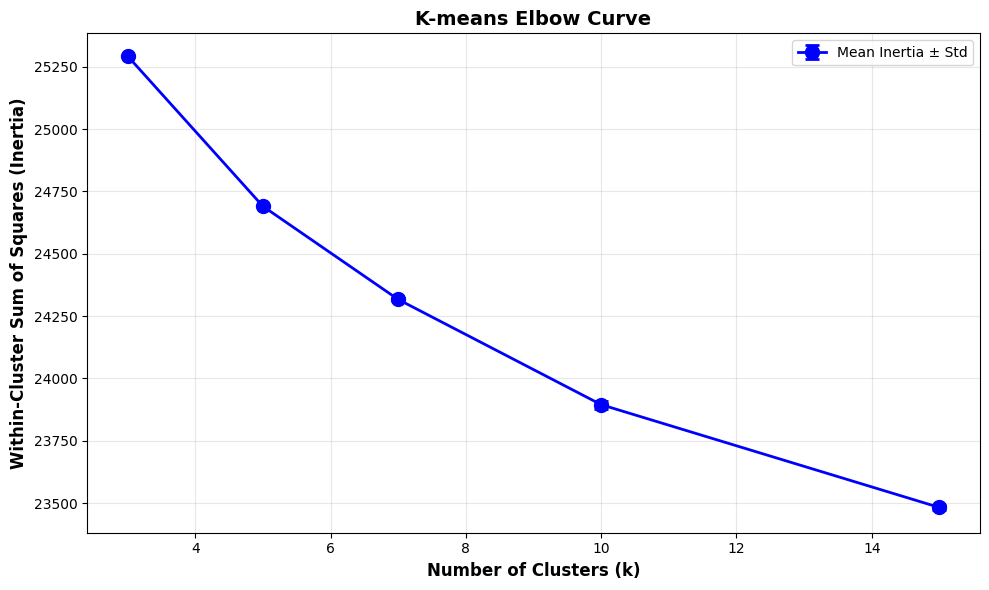

In [30]:

fig, ax = plt.subplots(figsize=(10, 6))


k_vals = []
inertia_means = []
inertia_stds = []

for k in CANDIDATE_K:
    k_data = kmeans_df[kmeans_df['k'] == k]
    k_vals.append(k)
    inertia_means.append(k_data['inertia'].mean())
    inertia_stds.append(k_data['inertia'].std())


ax.errorbar(k_vals, inertia_means, yerr=inertia_stds,
            marker='o', linewidth=2, markersize=10,
            color='blue', capsize=5, capthick=2,
            label='Mean Inertia ± Std')


ax.set_xlabel('Number of Clusters (k)', fontweight='bold', fontsize=12)
ax.set_ylabel('Within-Cluster Sum of Squares (Inertia)', fontweight='bold', fontsize=12)
ax.set_title('K-means Elbow Curve', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)



plt.tight_layout()
plt.savefig('../Outputs/kmeans_elbow_curve.png', dpi=300, bbox_inches='tight')
plt.show()


# HAC Multi K analysis

In [ ]:
print("HAC: MULTI K ANALYSIS")

SAMPLE_SIZE = 5000
np.random.seed(42)
sample_idx = np.random.choice(len(texts), SAMPLE_SIZE, replace=False)

X_hac_sample = X_tfidf[sample_idx].toarray()
texts_sample = [texts[i] for i in sample_idx]
labels_sample = true_labels[sample_idx]

hac_results = []


for k in CANDIDATE_K:
    print(f"k={k}...")
    

    hac = AgglomerativeClustering(n_clusters=k, linkage='ward')
    cluster_labels = hac.fit_predict(X_hac_sample)

    sil = silhouette_score(X_hac_sample, cluster_labels, metric='euclidean')
    ari = adjusted_rand_score(labels_sample, cluster_labels)
    nmi = normalized_mutual_info_score(labels_sample, cluster_labels)
    coh = get_coherence(texts_sample, cluster_labels, n_top=10)
    
    hac_results.append({
        'k': k,
        'silhouette': round(sil, 4),
        'ARI': round(ari, 4),
        'NMI': round(nmi, 4),
        'coherence': round(coh, 4),
        
    })
    
    print(f"  sil={sil:.4f}, ARI={ari:.4f}, NMI={nmi:.4f}, coh={coh:.4f}")


hac_df = pd.DataFrame(hac_results)




hac_df.to_csv('../Outputs/hac_results.csv', index=False)


HAC: MULTI K ANALYSIS
Testing k=[3, 5, 7, 10, 15] on 5,000 sampled documents

k=3...
  sil=0.0238, ARI=0.0096, NMI=0.0057, coh=0.6927
k=5...
  sil=0.0229, ARI=0.1581, NMI=0.1652, coh=0.7100
k=7...
  sil=0.0202, ARI=0.2043, NMI=0.2811, coh=0.7175
k=10...
  sil=0.0199, ARI=0.1581, NMI=0.2745, coh=0.6937
k=15...
  sil=0.0157, ARI=0.1066, NMI=0.2636, coh=0.6973


# HACDENDOGRAM sample size 2000

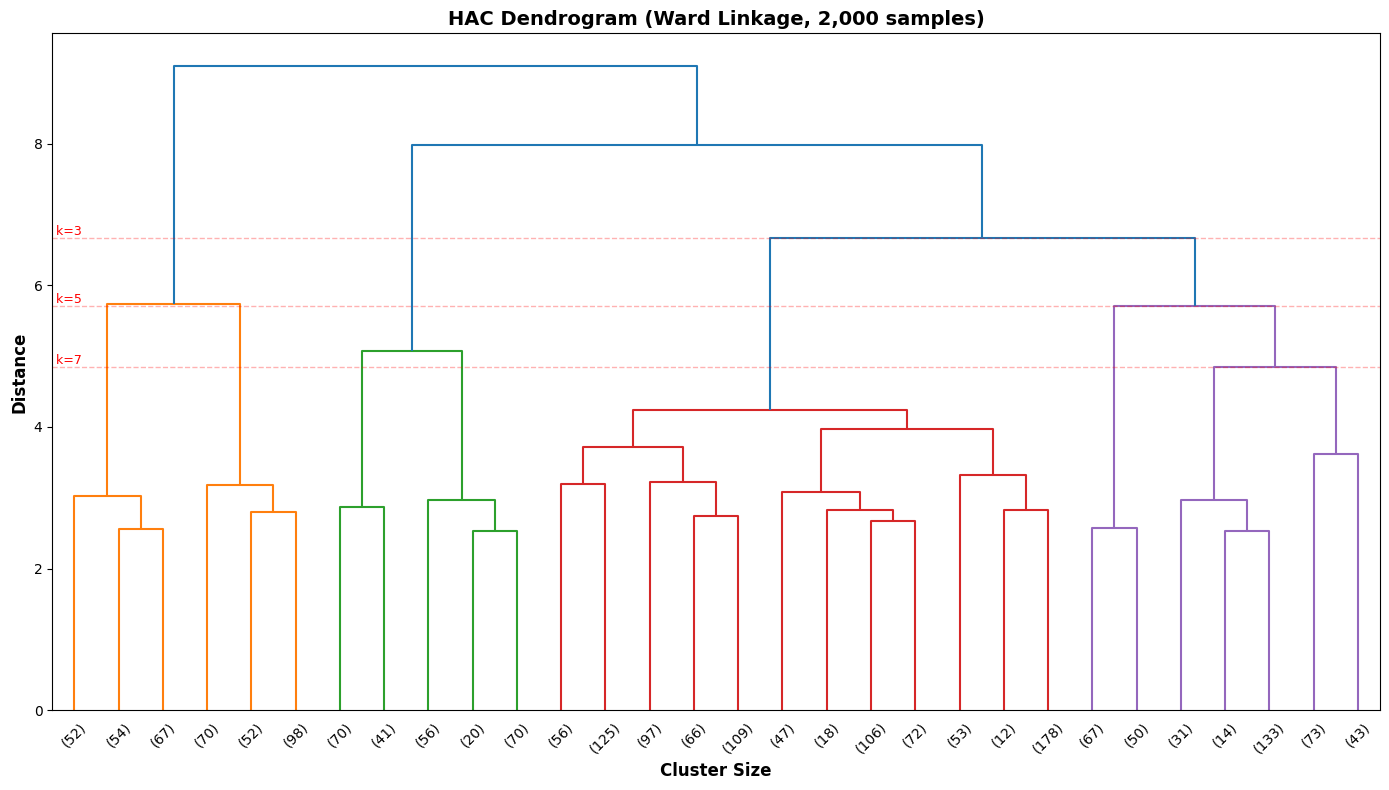

In [34]:


sample_size = 2000
sample_idx = np.random.RandomState(42).choice(len(texts), sample_size, replace=False)
X_sample = X_tfidf[sample_idx].toarray()

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 8))

dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',
    p=30,
    show_leaf_counts=True,
    leaf_font_size=10
)

ax.set_xlabel('Cluster Size', fontweight='bold', fontsize=12)
ax.set_ylabel('Distance', fontweight='bold', fontsize=12)
ax.set_title(f'HAC Dendrogram (Ward Linkage, {sample_size:,} samples)', 
             fontweight='bold', fontsize=14)


for k in [3, 5, 7]:
    ax.axhline(y=Z[-k, 2], color='red', linestyle='--', alpha=0.3, linewidth=1)
    ax.text(0, Z[-k, 2], f' k={k}', fontsize=9, color='red', va='bottom')

plt.tight_layout()
plt.savefig('../Outputs/hac_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()


# comparison k means vs hac (k=5)

In [38]:

print("COMPARISON: K-MEANS vs HAC (k=5)")


kmeans_k5 = kmeans_df[kmeans_df['k'] == 5]
kmeans_k5_mean = {
    'silhouette': kmeans_k5['silhouette'].mean(),
    'ARI': kmeans_k5['ARI'].mean(),
    'NMI': kmeans_k5['NMI'].mean(),
    'coherence': kmeans_k5['coherence'].mean(),
  
}


hac_k5 = hac_df[hac_df['k'] == 5].iloc[0]

comparison_df = pd.DataFrame({
    'Metric': ['Silhouette', 'ARI', 'NMI', 'Coherence'],
    'K-means': [
        round(kmeans_k5_mean['silhouette'], 4),
        round(kmeans_k5_mean['ARI'], 4),
        round(kmeans_k5_mean['NMI'], 4),
        round(kmeans_k5_mean['coherence'], 4),
  
    ],
    'HAC': [
        hac_k5['silhouette'],
        hac_k5['ARI'],
        hac_k5['NMI'],
        hac_k5['coherence'],
      
    ]
})

print("\n" + comparison_df.to_string(index=False))


print("\n" + "-"*70)
print("Final:")
for i, metric in enumerate(['Silhouette', 'ARI', 'NMI', 'Coherence', ]):
    km_val = comparison_df.iloc[i]['K-means']
    hac_val = comparison_df.iloc[i]['HAC']
    
    if abs(km_val - hac_val) < 0.0001:  # Essentially tied
        winner = 'Tie'
        diff = 0.0
    else:
        winner = 'K-means' if km_val > hac_val else 'HAC'
       
    
    print(f"  {metric:12s}: {winner:8s} ")

# Save
comparison_df.to_csv('../Outputs/kmeans_vs_hac_k5.csv', index=False)


COMPARISON: K-MEANS vs HAC (k=5)

    Metric  K-means    HAC
Silhouette   0.0604 0.0229
       ARI   0.2466 0.1581
       NMI   0.2452 0.1652
 Coherence   0.7737 0.7100

----------------------------------------------------------------------
Final:
  Silhouette  : K-means  
  ARI         : K-means  
  NMI         : K-means  
  Coherence   : K-means  


# kmeans hac baar hart comparison

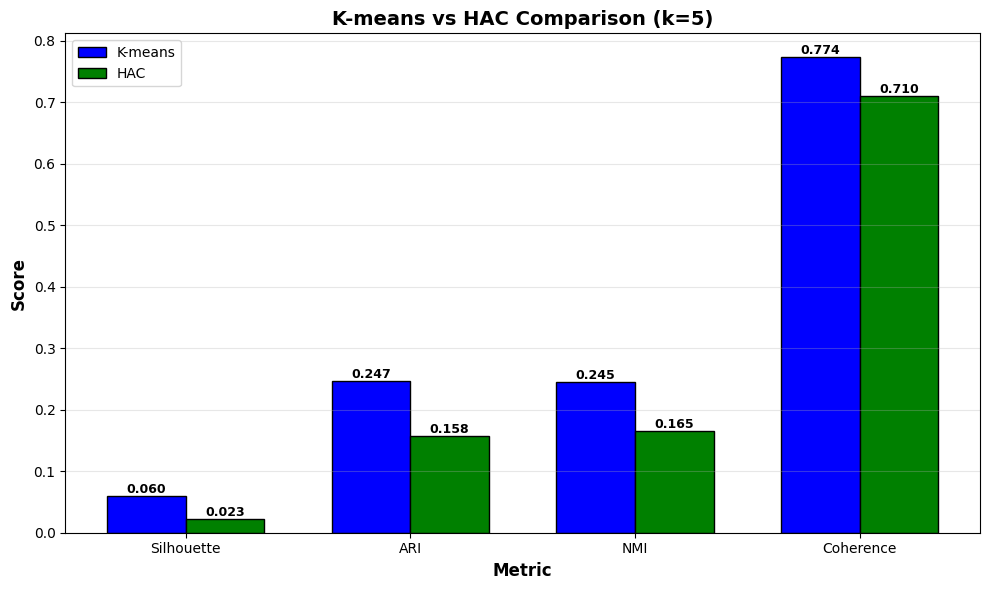

In [39]:

fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Silhouette', 'ARI', 'NMI', 'Coherence']
kmeans_scores = [
    kmeans_k5_mean['silhouette'],
    kmeans_k5_mean['ARI'],
    kmeans_k5_mean['NMI'],
    kmeans_k5_mean['coherence']
]
hac_scores = [
    hac_k5['silhouette'],
    hac_k5['ARI'],
    hac_k5['NMI'],
    hac_k5['coherence']
]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, kmeans_scores, width, label='K-means',
               color='blue', edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, hac_scores, width, label='HAC',
               color='green', edgecolor='black', linewidth=1)

ax.set_xlabel('Metric', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('K-means vs HAC Comparison (k=5)', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (km_score, hac_score) in enumerate(zip(kmeans_scores, hac_scores)):
    ax.text(i - width/2, km_score, f'{km_score:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.text(i + width/2, hac_score, f'{hac_score:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../Outputs/kmeans_vs_hac_barchart.png', dpi=300, bbox_inches='tight')
plt.show()
